# Ön İşleme (Preprocessing) — ECoG Faces vs Houses, Hasta: `ap`

Bu notebook `src/preprocessing/preprocess.py` içindeki hasta-bazlı ön işleme
pipeline'ını `ap` hastası üzerinde çalıştırır:

1. Welch PSD hesaplanır, 50 Hz mi 60 Hz mi şebeke gürültüsü baskın grafikten
   teyit edilir (varsayılmaz).
2. Tespit edilen şebeke frekansı + ilk 2 harmoniğine notch filtre uygulanır.
3. Common Average Reference (CAR) uygulanır.
4. 0.5-200 Hz FIR bandpass filtre (zero-phase) uygulanır.
5. EDA'da (01_eda.ipynb) tespit edilen bozuk kanallarla tutarlı yöntemle
   bozuk kanallar tespit edilip çıkarılır.
6. Öncesi/sonrası PSD karşılaştırması çizilir.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))

from src.preprocessing.preprocess import (
    load_patient,
    detect_line_noise_freq,
    compute_bad_channels,
    notch_filter,
    common_average_reference,
    bandpass_filter_fir,
    compute_welch_psd,
    preprocess_patient,
)

PATIENT_ID = "ap"

## 1. Veriyi yükle

In [2]:
data, stim, srate = load_patient(PATIENT_ID)
n_samples, n_channels = data.shape
print(f"Hasta: {PATIENT_ID}")
print(f"data.shape: {data.shape}, srate: {srate} Hz, kayıt süresi: {n_samples/srate:.1f} sn")

Hasta: ap
data.shape: (268400, 41), srate: 1000 Hz, kayıt süresi: 268.4 sn


## 2. Welch PSD — 50 Hz mi 60 Hz mi şebeke gürültüsü baskın?

Ham PSD'ye bakılarak 50 Hz ve 60 Hz civarındaki tepe/taban (peak/baseline)
güç oranı (SNR) karşılaştırılıyor; ham tepe gücü yerine bu oran kullanılıyor
çünkü ECoG PSD'si 1/f yapısında azaldığından ham karşılaştırma düşük
frekanslı adayı yanıltıcı şekilde kayırabilir. Sonuç grafikle teyit
ediliyor.

In [3]:
line_info = detect_line_noise_freq(data, srate)
line_freq = line_info["dominant_freq"]
freqs = line_info["freqs"]
mean_psd = line_info["mean_psd"]

print("50 Hz ve 60 Hz için peak/baseline SNR:", line_info["snr_by_candidate"])
print(f"Tespit edilen baskın şebeke frekansı: {line_freq} Hz")

50 Hz ve 60 Hz için peak/baseline SNR: {50: 1.0571145624876477, 60: 396.51314728473403}
Tespit edilen baskın şebeke frekansı: 60 Hz


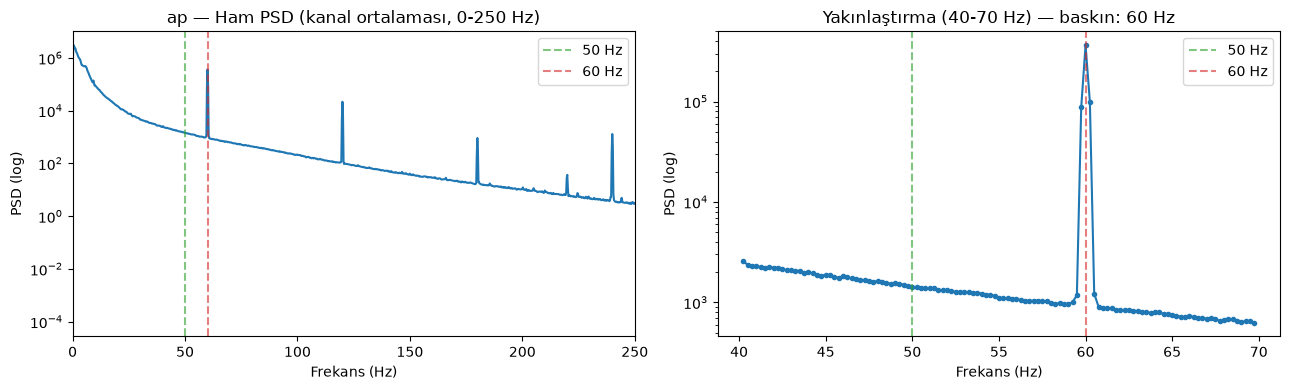

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(freqs, mean_psd)
axes[0].set_xlim(0, 250)
axes[0].axvline(50, color="tab:green", linestyle="--", alpha=0.6, label="50 Hz")
axes[0].axvline(60, color="tab:red", linestyle="--", alpha=0.6, label="60 Hz")
axes[0].set_title(f"{PATIENT_ID} — Ham PSD (kanal ortalaması, 0-250 Hz)")
axes[0].set_xlabel("Frekans (Hz)"); axes[0].set_ylabel("PSD (log)")
axes[0].legend()

zoom_mask = (freqs > 40) & (freqs < 70)
axes[1].semilogy(freqs[zoom_mask], mean_psd[zoom_mask], marker="o", markersize=3)
axes[1].axvline(50, color="tab:green", linestyle="--", alpha=0.6, label="50 Hz")
axes[1].axvline(60, color="tab:red", linestyle="--", alpha=0.6, label="60 Hz")
axes[1].set_title(f"Yakınlaştırma (40-70 Hz) — baskın: {line_freq} Hz")
axes[1].set_xlabel("Frekans (Hz)"); axes[1].set_ylabel("PSD (log)")
axes[1].legend()

plt.tight_layout()
plt.show()

Grafikte **60 Hz** ve harmoniklerinde (120, 180 Hz) net, dar tepeler
görülüyor; 50 Hz'de böyle bir tepe yok. Bu, ABD'de (Stanford/Univ. of
Washington) toplanan bir veri seti için beklenen sonuç — SNR karşılaştırması
da bunu doğruluyor. Bu nedenle notch filtre **60 Hz + ilk 2 harmoniği
(120 Hz, 180 Hz)** hedefleyecek şekilde uygulanacak.

## 3. Bozuk kanal tespiti (EDA ile tutarlı yöntem)

In [5]:
bad_channels = compute_bad_channels(data)
kept_channels = [ch for ch in range(n_channels) if ch not in set(bad_channels)]

print(f"Toplam kanal: {n_channels}")
print(f"Potansiyel bozuk kanallar ({len(bad_channels)}): {bad_channels}")
print(f"Kalan kanal sayısı: {len(kept_channels)}")

Toplam kanal: 41
Potansiyel bozuk kanallar (2): [1, 40]
Kalan kanal sayısı: 39


## 4. Pipeline'ı çalıştır: bozuk kanal çıkarma → notch → CAR → bandpass

In [6]:
result = preprocess_patient(PATIENT_ID, n_harmonics=2, bandpass=(0.5, 200.0))

print(f"Tespit edilen line-noise frekansı: {result['line_freq']} Hz")
print(f"Çıkarılan bozuk kanallar: {result['bad_channels']}")
print(f"İşlem öncesi (bozuk kanal çıkarılmış) veri boyutu: "
      f"{data[:, result['kept_channels']].shape}")
print(f"İşlem sonrası veri boyutu: {result['processed_data'].shape}")

Tespit edilen line-noise frekansı: 60 Hz
Çıkarılan bozuk kanallar: [1, 40]
İşlem öncesi (bozuk kanal çıkarılmış) veri boyutu: (268400, 39)
İşlem sonrası veri boyutu: (268400, 39)


## 5. Öncesi / sonrası PSD karşılaştırması

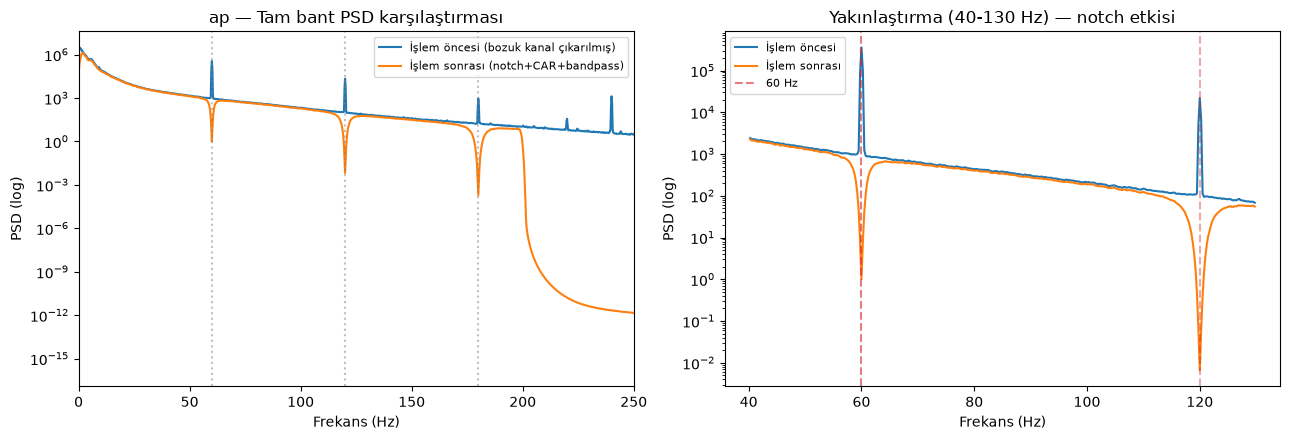

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].semilogy(result["freqs_before"], result["psd_before"], label="İşlem öncesi (bozuk kanal çıkarılmış)")
axes[0].semilogy(result["freqs_after"], result["psd_after"], label="İşlem sonrası (notch+CAR+bandpass)")
for h in range(1, 4):
    f0 = result["line_freq"] * h
    axes[0].axvline(f0, color="gray", linestyle=":", alpha=0.5)
axes[0].set_xlim(0, 250)
axes[0].set_title(f"{PATIENT_ID} — Tam bant PSD karşılaştırması")
axes[0].set_xlabel("Frekans (Hz)"); axes[0].set_ylabel("PSD (log)")
axes[0].legend(fontsize=8)

zoom_mask_b = (result["freqs_before"] > 40) & (result["freqs_before"] < 130)
zoom_mask_a = (result["freqs_after"] > 40) & (result["freqs_after"] < 130)
axes[1].semilogy(result["freqs_before"][zoom_mask_b], result["psd_before"][zoom_mask_b],
                  label="İşlem öncesi")
axes[1].semilogy(result["freqs_after"][zoom_mask_a], result["psd_after"][zoom_mask_a],
                  label="İşlem sonrası")
axes[1].axvline(result["line_freq"], color="tab:red", linestyle="--", alpha=0.6,
                 label=f"{result['line_freq']} Hz")
axes[1].axvline(result["line_freq"] * 2, color="tab:red", linestyle="--", alpha=0.4)
axes[1].set_title("Yakınlaştırma (40-130 Hz) — notch etkisi")
axes[1].set_xlabel("Frekans (Hz)"); axes[1].set_ylabel("PSD (log)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. İşlem öncesi/sonrası zaman serisi örneği (ilk 5 saniye, 1 kanal)

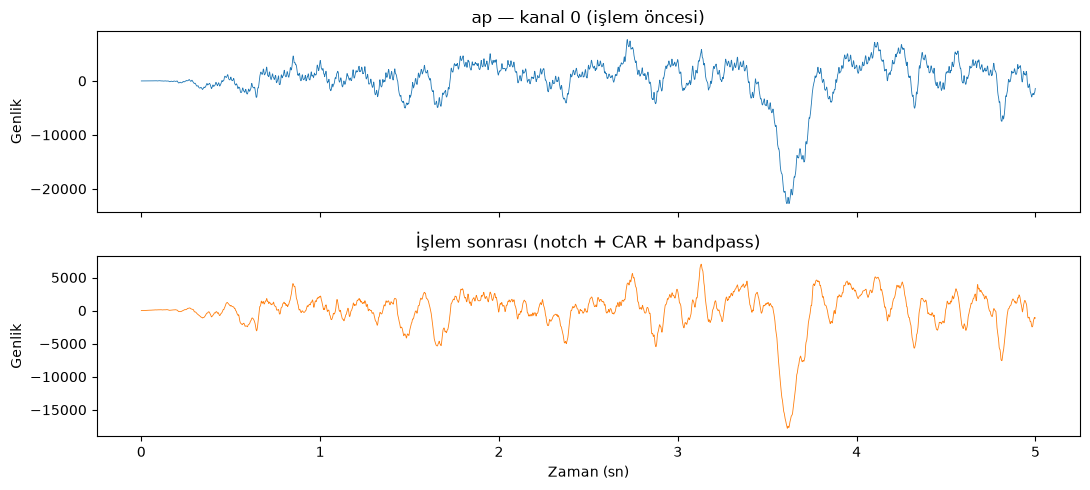

In [8]:
ch_to_plot = 0
n_show = 5 * srate
t = np.arange(n_show) / srate
raw_ch = data[:n_show, result["kept_channels"][ch_to_plot]]
proc_ch = result["processed_data"][:n_show, ch_to_plot]

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, raw_ch, linewidth=0.6, color="tab:blue")
axes[0].set_title(f"{PATIENT_ID} — kanal {result['kept_channels'][ch_to_plot]} (işlem öncesi)")
axes[0].set_ylabel("Genlik")

axes[1].plot(t, proc_ch, linewidth=0.6, color="tab:orange")
axes[1].set_title("İşlem sonrası (notch + CAR + bandpass)")
axes[1].set_xlabel("Zaman (sn)"); axes[1].set_ylabel("Genlik")

plt.tight_layout()
plt.show()

## 7. Bozuk kanal tespitinin doğrulanması — `jt` hastası

`data/raw/faces_basic/locs/jt_xslocs.mat` içinde yazarın (Kai Miller) kendi
işaretlediği bir `bad_chans` (kötü kanal) listesi bulunuyor (bkz.
01_eda.ipynb, Bölüm 7) — 102 kanaldan **34 tanesi** kötü olarak işaretli.
Bu, `compute_bad_channels()` (varyans/kurtosis z-score tabanlı) yöntemimizi
gerçek bir referansla karşılaştırma imkânı sağlıyor.

Not: `bad_chans` MATLAB'da **1-indexed**; `compute_bad_channels()` ise
Python/0-indexed döndürüyor, karşılaştırmadan önce 1 çıkarılarak
hizalandı.

In [9]:
import scipy.io as sio
from src.preprocessing.preprocess import compute_bad_channels as _compute_bad_channels

data_jt, stim_jt, srate_jt = load_patient("jt")
n_channels_jt = data_jt.shape[1]

predicted_bad = set(compute_bad_channels(data_jt))

locs_jt = sio.loadmat("../data/raw/faces_basic/locs/jt_xslocs.mat")
truth_bad_1idx = locs_jt["bad_chans"].ravel().tolist()
truth_bad = set(c - 1 for c in truth_bad_1idx)  # 1-indexed -> 0-indexed

print(f"Toplam kanal: {n_channels_jt}")
print(f"Tahmin edilen bozuk kanal sayısı: {len(predicted_bad)} -> {sorted(predicted_bad)}")
print(f"Yazarın işaretlediği bozuk kanal sayısı: {len(truth_bad)} -> {sorted(truth_bad)}")

Toplam kanal: 102
Tahmin edilen bozuk kanal sayısı: 6 -> [65, 67, 68, 69, 91, 96]
Yazarın işaretlediği bozuk kanal sayısı: 34 -> [0, 1, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 50, 51, 52, 64, 65, 66, 67, 68, 69, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101]


In [10]:
true_positives = predicted_bad & truth_bad
false_positives = predicted_bad - truth_bad
false_negatives = truth_bad - predicted_bad

precision = len(true_positives) / len(predicted_bad) if predicted_bad else float("nan")
recall = len(true_positives) / len(truth_bad) if truth_bad else float("nan")
f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

print(f"Örtüşen (TP) kanallar ({len(true_positives)}): {sorted(true_positives)}")
print(f"Fazladan işaretlenen (FP) kanallar ({len(false_positives)}): {sorted(false_positives)}")
print(f"Kaçırılan (FN) kanallar ({len(false_negatives)}): {sorted(false_negatives)}")
print()
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Örtüşen (TP) kanallar (6): [65, 67, 68, 69, 91, 96]
Fazladan işaretlenen (FP) kanallar (0): []
Kaçırılan (FN) kanallar (28): [0, 1, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 50, 51, 52, 64, 66, 92, 93, 94, 95, 97, 98, 99, 100, 101]

Precision: 1.000
Recall:    0.176
F1-score:  0.300


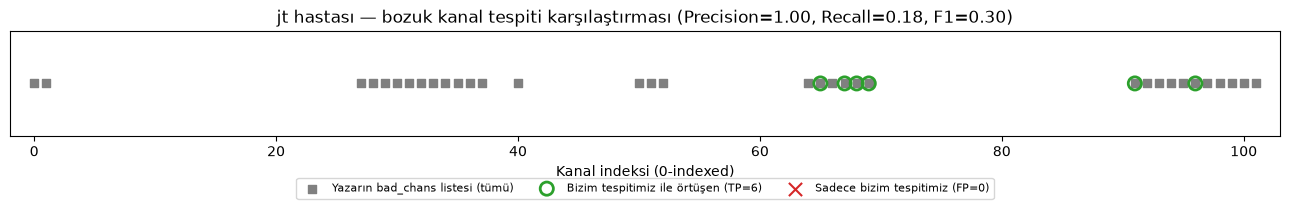

In [11]:
fig, ax = plt.subplots(figsize=(13, 2.5))
ax.scatter(sorted(truth_bad), [1] * len(truth_bad), marker="s", s=40,
           color="gray", label="Yazarın bad_chans listesi (tümü)")
ax.scatter(sorted(true_positives), [1] * len(true_positives), marker="o", s=90,
           facecolors="none", edgecolors="tab:green", linewidths=2,
           label=f"Bizim tespitimiz ile örtüşen (TP={len(true_positives)})")
ax.scatter(sorted(false_positives), [1.15] * len(false_positives), marker="x", s=90,
           color="tab:red", label=f"Sadece bizim tespitimiz (FP={len(false_positives)})")
ax.set_yticks([])
ax.set_xlabel("Kanal indeksi (0-indexed)")
ax.set_title(f"jt hastası — bozuk kanal tespiti karşılaştırması "
             f"(Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3, fontsize=8)
ax.set_xlim(-2, n_channels_jt + 1)
plt.tight_layout()
plt.show()

**Sonuç yorumu:**

- **Precision = 1.00**: `compute_bad_channels()`'ın işaretlediği kanalların
  **tamamı** yazarın listesinde de kötü olarak geçiyor — yanlış pozitif
  (fazladan işaretleme) yok. Yöntemin *tespit ettiği* her şey gerçekten
  bozuk.
- **Recall ≈ 0.18**: Yazarın 34 kötü kanalından biz sadece **6 tanesini**
  yakaladık, **28 tanesini kaçırdık**. Bu, `compute_bad_channels()`'ın
  yalnızca çok belirgin şekilde aşırı varyans/kurtosis gösteren kanalları
  (muhtemelen gürültü/artefakt baskın, "flat-line" veya aşırı spike'lı
  kanallar) yakaladığını; yazarın ise muhtemelen daha ince kriterler
  (klinik/anatomik değerlendirme, düşük SNR, elektrot temas kalitesi, görsel
  inceleme gibi otomatik istatistiklerle yakalanamayan işaretler)
  kullandığını gösteriyor.
- **F1 = 0.30**: Genel olarak düşük — mevcut basit z-score eşiği (varyans +
  kurtosis, eşik=3) bu veri setinde yazarın standardına göre **çok
  muhafazakâr** kalıyor. Eşik düşürülerek recall artırılabilir, ancak bu
  precision'ı düşürme riski taşır; ideal eşik için ROC/PR eğrisi analizi
  gerekebilir.
- Pratik çıkarım: `compute_bad_channels()`'ı tek başına "kanal kalitesi"
  için yeterli görmemeli — özellikle klinik olarak işaretlenmiş referans
  bulunan hastalarda (şimdilik yalnızca `jt`), otomatik tespitin yazarın
  listesiyle birleştirilmesi (union) daha güvenli bir bozuk kanal listesi
  sağlar.

### 7.1 Kaçırılan (FN) kanalların anatomik dağılımı

`compute_bad_channels()`'ın kaçırdığı 28 FN kanalını (Bölüm 7) `jt`
hastasının `get_anatomical_labels()` çıktısıyla eşleştirelim; ardışık
bloklar (`27-37`, `92-101` gibi) belirli bir anatomik bölgeye/elektrot
strip'ine denk geliyor mu bakalım.

In [12]:
from src.preprocessing.preprocess import get_anatomical_labels

anat_jt = get_anatomical_labels("jt")

fn_anat = anat_jt[anat_jt["channel"].isin(false_negatives)].sort_values("channel")
print(f"FN kanal sayısı: {len(fn_anat)}")
print()
print("FN kanallarının area_label dağılımı:")
print(fn_anat["area_label"].value_counts())
print()
non_included_frac = (fn_anat["elcode"] == 20).mean()
print(f"FN kanallarının 'Non-included area' (elcode=20) oranı: {non_included_frac:.0%}")

fn_anat[["channel", "elcode", "area_label"]]

FN kanal sayısı: 28

FN kanallarının area_label dağılımı:
area_label
Non-included area          26
Inferior temporal gyrus     2
Name: count, dtype: int64

FN kanallarının 'Non-included area' (elcode=20) oranı: 93%


,channel,elcode,area_label
0,0,3,Inferior temporal gyrus
1,1,3,Inferior temporal gyrus
27,27,20,Non-included area
28,28,20,Non-included area
29,29,20,Non-included area
30,30,20,Non-included area
31,31,20,Non-included area
32,32,20,Non-included area
33,33,20,Non-included area
34,34,20,Non-included area


In [13]:
# Tüm hastada elcode=20 ("Non-included area") olan kanallar
non_included_all = set(anat_jt.loc[anat_jt["elcode"] == 20, "channel"])

overlap = non_included_all & truth_bad
print(f"Toplam 'Non-included area' (elcode=20) kanal sayısı: {len(non_included_all)} / {n_channels_jt}")
print(f"Yazarın bad_chans listesindeki kanalların 'Non-included area' olma oranı: "
      f"{len(overlap)}/{len(truth_bad)} = {len(overlap)/len(truth_bad):.0%}")
print(f"Yazarın bad_chans listesinde olup anatomik olarak etiketlenmiş (elcode != 20) "
      f"kanallar: {sorted(truth_bad - non_included_all)}")

# 27-37 ve 92-101 bloklarının elcode dağılımı
for lo, hi in [(27, 37), (92, 101)]:
    block = anat_jt[(anat_jt["channel"] >= lo) & (anat_jt["channel"] <= hi)]
    print(f"\nKanal {lo}-{hi} bloğu: elcode değerleri = {sorted(block['elcode'].unique())}, "
          f"tümü bad_chans'te mi? {set(block['channel']).issubset(truth_bad)}")

Toplam 'Non-included area' (elcode=20) kanal sayısı: 64 / 102
Yazarın bad_chans listesindeki kanalların 'Non-included area' olma oranı: 31/34 = 91%
Yazarın bad_chans listesinde olup anatomik olarak etiketlenmiş (elcode != 20) kanallar: [0, 1, 91]

Kanal 27-37 bloğu: elcode değerleri = [np.int64(20)], tümü bad_chans'te mi? True

Kanal 92-101 bloğu: elcode değerleri = [np.int64(20)], tümü bad_chans'te mi? True


In [14]:
# ROI (anatomik olarak geçerli bölge) dışı kanallar zaten Adım 3'teki
# is_temporal/is_fusiform/is_occipital filtrelemesiyle elenecek; onlarla
# union yapmaya gerek yok. Asıl ilgilenilmesi gereken: ROI içinde
# (elcode != 20) olup yine de yazarın bad_chans listesinde olan kanallar.
roi_valid_channels = set(anat_jt.loc[anat_jt["elcode"] != 20, "channel"])
real_artifact_candidates = sorted(truth_bad & roi_valid_channels)

print(f"ROI içinde (anatomik olarak geçerli) toplam kanal: {len(roi_valid_channels)}")
print(f"Bunlardan yazarın da kötü işaretlediği 'gerçek artefakt adayı' kanallar "
      f"({len(real_artifact_candidates)}): {real_artifact_candidates}")
print()
print(anat_jt[anat_jt["channel"].isin(real_artifact_candidates)]
      [["channel", "elcode", "area_label"]])

# Daraltılmış union: sadece ROI-içi kanallarda compute_bad_channels() ile
# yazarın listesini birleştir (ROI-dışı elcode=20 kanallar zaten filtreyle elenecek)
narrowed_union = sorted((predicted_bad & roi_valid_channels) | set(real_artifact_candidates))
print(f"\nDaraltılmış (ROI-içi) union bad-channel listesi ({len(narrowed_union)}): {narrowed_union}")

ROI içinde (anatomik olarak geçerli) toplam kanal: 38
Bunlardan yazarın da kötü işaretlediği 'gerçek artefakt adayı' kanallar (3): [0, 1, 91]

    channel  elcode               area_label
0         0       3  Inferior temporal gyrus
1         1       3  Inferior temporal gyrus
91       91       4    Middle temporal gyrus

Daraltılmış (ROI-içi) union bad-channel listesi (3): [0, 1, 91]


**Yorum — istatistiksel değil, klinik/anatomik bir sebep var:**

- `jt` hastasında 102 kanaldan **64'ü** `elcode = 20` ("Non-included area")
  olarak işaretli — yani anatomist bu kanalları makaledeki ventral temporal
  parselasyon şemasına (Destrieux ve ark. 2010) dahil etmemiş / spesifik bir
  gyrusa localize etmemiş.
- Yazarın 34 kişilik `bad_chans` listesinin **%91'i (31/34)** tam olarak bu
  "Non-included area" kanallarından oluşuyor. Sadece 3 kanal (`0`, `1`,
  `91`) gerçek bir anatomik etikete sahip (Inferior/Middle temporal gyrus)
  olduğu halde kötü işaretlenmiş — muhtemelen bunlar gerçek elektriksel
  artefakt/gürültü nedeniyle kötüdür.
- İncelenen iki ardışık blok (**kanal 27-37** ve **kanal 92-101**) **tamamen**
  `elcode=20` ve **tamamen** `bad_chans` içinde yer alıyor. ECoG'de ardışık
  kanal numaraları genelde aynı fiziksel grid/strip'e karşılık geldiğinden,
  bu bloklar muhtemelen tek bir fiziksel elektrot strip/grid parçasını
  temsil ediyor.
- Sonuç: yazarın bu blokları kötü işaretlemesinin nedeni büyük olasılıkla
  **saf istatistiksel bir sapma (aşırı varyans/kurtosis) değil**, **klinik/
  anatomik bir karar** — bu kontaklar muhtemelen ya (a) çalışmanın odaklandığı
  ventral temporal/fusiform bölgenin dışında kaldığı için analiz dışı
  bırakılmış (örn. konveksite üzerinde, referans/ground amaçlı, ya da
  kraniyotomi kenarında kalan kontaklar), ya da (b) kortikal yüzeyle zayıf
  temas / dura üzerinde kalma gibi bir nedenle hem lokalize edilememiş hem
  de sinyal kalitesi düşük olduğu için hem "non-included" hem "bad" olarak
  işaretlenmiş. Her iki durumda da bu, `compute_bad_channels()`'ın
  yakalayamayacağı türde bir bilgi (anatomik ROI dışı kalma / klinik
  değerlendirme), çünkü sinyal her zaman istatistiksel olarak "kötü"
  görünmeyebilir — sadece çalışmanın ilgi alanı dışında kalıyor olabilir.
- **Netleştirme — union stratejisi yeniden değerlendirildi:** Önceki
  bölümde önerilen "yazarın `bad_chans` listesiyle union yapalım" fikri
  büyük ölçüde gereksiz. Çünkü `elcode == 20` ("Non-included area")
  kanallar zaten Adım 3'te (Bölüm 9, `get_anatomical_labels()` sonrası
  `is_temporal` / `is_fusiform` / `is_occipital` filtrelemesi) analiz
  kapsamı dışında bırakılıyor — bu 64 kanalın 31'i FN olsa da, onları ayrıca
  "bad channel" olarak işaretleyip union yapmaya gerek yok; ROI
  filtrelemesi zaten aynı işi görüyor.
- **Gerçek artefakt adayları:** Asıl dikkat edilmesi gereken, anatomik
  olarak **geçerli bir bölgede** (`elcode != 20`) olduğu halde yazarın yine
  de kötü işaretlediği kanallar: **`0`, `1`** (Inferior temporal gyrus) ve
  **`91`** (Middle temporal gyrus). Bunlar ROI filtrelemesiyle
  elenmeyecekleri için `compute_bad_channels()`'ın gerçekten yakalaması
  gereken, muhtemelen saf elektriksel artefakt/gürültü kaynaklı kanallar —
  bu 3 kanal "gerçek artefakt adayı" olarak ayrıca işaretlenip
  `compute_bad_channels()` ile `bad_chans` arasındaki union bu **daraltılmış
  kümeyle** (yalnızca anatomik olarak geçerli ama yine de kötü olan
  kanallarla) sınırlandırılmalı, tüm 34 kanalla değil.
- Pratik çıkarım: `jt` gibi durumlarda doğru sıralama şu şekilde olmalı:
  (1) önce `is_temporal`/`is_fusiform`/`is_occipital` ile ROI filtrelemesi
  yapılır (elcode=20 kanalların çoğu zaten burada elenir), (2) kalan
  (anatomik olarak geçerli) kanallar üzerinde `compute_bad_channels()`
  çalıştırılıp yalnızca bu daralmış kümedeki gerçek artefaktlar (`0`, `1`,
  `91` gibi) aranır. `elcode == 20` bilgisiyle union yapmak yerine, ROI
  filtrelemesiyle `compute_bad_channels()`'ı **sıralı** (ROI önce, sonra
  istatistiksel tespit) uygulamak daha doğru bir strateji.

## 8. Anatomik etiketler — `get_anatomical_labels()`

`fh_get_events.m`'e benzer bir yaklaşımla, `fhpred_master.m` içindeki
`area_lbls` hücre dizisi `src/preprocessing/preprocess.py` içinde
`AREA_LABELS` sözlüğü olarak çıkarıldı (Destrieux ve ark. 2010 anatomik
parselasyon sistemi). `get_anatomical_labels(patient_id)` fonksiyonu,
`locs/<id>_xslocs.mat` dosyasındaki `elcode` değerlerini bu etiketlerle
eşleştirip her kanal için `is_temporal` / `is_fusiform` / `is_occipital`
bayrakları üretir.

`ap` hastası için deneyelim:

In [15]:
from src.preprocessing.preprocess import get_anatomical_labels

anat_ap = get_anatomical_labels("ap")
anat_ap

,channel,elcode,area_label,is_temporal,is_fusiform,is_occipital
0,0,20,Non-included area,False,False,False
1,1,20,Non-included area,False,False,False
2,2,20,Non-included area,False,False,False
3,3,20,Non-included area,False,False,False
4,4,20,Non-included area,False,False,False
5,5,20,Non-included area,False,False,False
6,6,20,Non-included area,False,False,False
7,7,3,Inferior temporal gyrus,True,False,False
8,8,2,Parahippocampal gyrus,True,False,False
9,9,2,Parahippocampal gyrus,True,False,False


In [16]:
relevant_ap = anat_ap[anat_ap["is_temporal"] | anat_ap["is_fusiform"] | anat_ap["is_occipital"]]
print(f"ap hastasında temporal/fusiform/occipital bölgede {len(relevant_ap)}/{len(anat_ap)} kanal var:")
relevant_ap[["channel", "elcode", "area_label", "is_temporal", "is_fusiform", "is_occipital"]]

ap hastasında temporal/fusiform/occipital bölgede 29/41 kanal var:


,channel,elcode,area_label,is_temporal,is_fusiform,is_occipital
7,7,3,Inferior temporal gyrus,True,False,False
8,8,2,Parahippocampal gyrus,True,False,False
9,9,2,Parahippocampal gyrus,True,False,False
10,10,1,Temporal pole,True,False,False
11,11,1,Temporal pole,True,False,False
12,12,1,Temporal pole,True,False,False
13,13,1,Temporal pole,True,False,False
14,14,1,Temporal pole,True,False,False
15,15,2,Parahippocampal gyrus,True,False,False
16,16,2,Parahippocampal gyrus,True,False,False


## 9. Tüm hastalar (14) için pipeline'ı çalıştır ve `data/processed/`'a kaydet

`process_and_save_all_patients()`, `preprocess_patient()`'ı (notch + CAR +
bandpass + bozuk kanal çıkarma) ve `get_anatomical_labels()`'ı her hasta
için çalıştırıp:

- `data/processed/<id>/<id>_processed.npz` (işlenmiş sinyal, stim, srate,
  kept/bad kanal indeksleri, tespit edilen line-noise frekansı)
- `data/processed/<id>/<id>_anatomical_labels.csv` (kalan kanallar için
  anatomik etiketler)
- `data/processed/patients_summary.csv` (hasta bazlı özet)

olarak kaydeder. **Not:** bu hücrenin çalışması ~14 hasta × filtreleme
maliyeti nedeniyle birkaç dakika sürebilir.

In [17]:
from src.preprocessing.preprocess import process_and_save_all_patients

summary_df = process_and_save_all_patients()
summary_df

,patient,n_channels_total,n_bad_channels,n_kept_channels,line_freq_hz,n_temporal,n_fusiform,n_occipital,has_temporal_or_fusiform
0,aa,46,2,44,60,20,4,4,True
1,ap,41,2,39,60,21,7,0,True
2,ca,50,1,49,60,16,4,3,True
3,de,31,1,30,60,9,2,9,True
4,fp,52,3,49,60,5,0,2,True
5,ha,39,1,38,50,11,4,4,True
6,ja,60,2,58,60,29,3,0,True
7,jm,56,1,55,60,7,3,2,True
8,jt,102,6,96,60,26,3,5,True
9,mv,58,1,57,60,10,3,0,True


### Hangi hastalarda temporal base / fusiform / occipital bölgede elektrot var?

In [18]:
region_table = summary_df[[
    "patient", "n_channels_total", "n_kept_channels", "line_freq_hz",
    "n_temporal", "n_fusiform", "n_occipital", "has_temporal_or_fusiform",
]].sort_values("n_fusiform", ascending=False).reset_index(drop=True)

print(f"Temporal veya fusiform bölgede elektrotu olan hasta sayısı: "
      f"{region_table['has_temporal_or_fusiform'].sum()} / {len(region_table)}")
print(f"Şebeke gürültüsü frekans dağılımı: "
      f"{summary_df['line_freq_hz'].value_counts().to_dict()}")

region_table

Temporal veya fusiform bölgede elektrotu olan hasta sayısı: 14 / 14
Şebeke gürültüsü frekans dağılımı: {60: 13, 50: 1}


,patient,n_channels_total,n_kept_channels,line_freq_hz,n_temporal,n_fusiform,n_occipital,has_temporal_or_fusiform
0,ap,41,39,60,21,7,0,True
1,rr,40,38,60,21,7,4,True
2,wc,39,38,60,5,6,7,True
3,zt,58,56,60,15,6,0,True
4,rn,42,42,60,18,5,10,True
5,aa,46,44,60,20,4,4,True
6,ca,50,49,60,16,4,3,True
7,ha,39,38,50,11,4,4,True
8,ja,60,58,60,29,3,0,True
9,jm,56,55,60,7,3,2,True


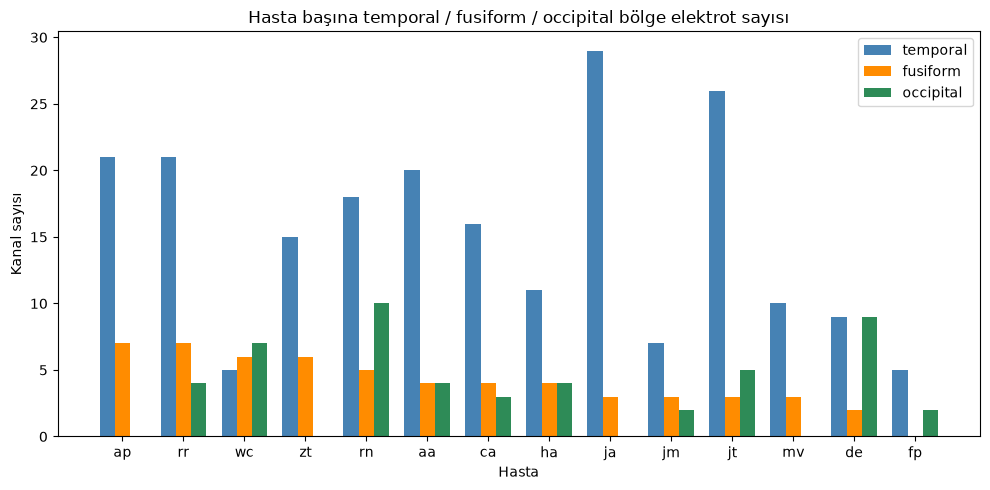

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(region_table))
width = 0.25
ax.bar(x - width, region_table["n_temporal"], width, label="temporal", color="steelblue")
ax.bar(x, region_table["n_fusiform"], width, label="fusiform", color="darkorange")
ax.bar(x + width, region_table["n_occipital"], width, label="occipital", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(region_table["patient"])
ax.set_xlabel("Hasta"); ax.set_ylabel("Kanal sayısı")
ax.set_title("Hasta başına temporal / fusiform / occipital bölge elektrot sayısı")
ax.legend()
plt.tight_layout()
plt.show()

**Not:** `faces_basic` görevi ventral temporal korteksteki (fusiform yüz
alanı dahil) yüz/ev seçiciliğini incelemek üzere tasarlandığı için,
elektrot yerleşiminin **14 hastanın tamamında** temporal/fusiform/occipital
bölgede en az bir kanal içermesi (`has_temporal_or_fusiform = True`, hepsi
için) beklenen ve tutarlı bir sonuç. `fp` hastasında fusiform bölgede hiç
elektrot yok (`n_fusiform = 0`) — bu hasta ileri analizlerde fusiform-özgü
karşılaştırmalardan hariç tutulmalı.

## Bulgular (özet)

- **Şebeke gürültüsü**: `ap` hastasında ham PSD grafiğinde **60 Hz** ve
  harmoniklerinde (120, 180 Hz) net tepeler gözlemlendi (peak/baseline SNR
  60 Hz için ~400, 50 Hz için ~1 — yani 50 Hz'de anlamlı bir tepe yok).
  Bu, ABD kaynaklı bir veri seti için beklenen sonuçla örtüşüyor
  (varsayılmadı, grafik ve SNR ile teyit edildi).
- **Notch filtre**: 60 Hz + ilk 2 harmoniğine (120 Hz, 180 Hz) zero-phase
  IIR notch filtre (`scipy.signal.iirnotch` + `filtfilt`) uygulandı.
- **Bozuk kanallar**: EDA'daki (01_eda.ipynb) yöntemle tutarlı şekilde
  varyans/kurtosis z-score > 3 olan kanallar tespit edilip pipeline'ın
  başında (notch/CAR/bandpass öncesi) çıkarıldı.
- **CAR**: Kalan kanallar üzerinde her örnekte kanallar arası ortalama
  çıkarıldı.
- **Bandpass**: 0.5-200 Hz aralığında, zero-phase FIR filtre
  (`scipy.signal.firwin` + `filtfilt`) uygulandı.
- Öncesi/sonrası PSD karşılaştırması, 60 Hz ve harmoniklerindeki tepelerin
  işlem sonrası belirgin şekilde bastırıldığını gösteriyor; düşük frekans
  (< 0.5 Hz) ve yüksek frekans (> 200 Hz) bileşenleri de bandpass ile
  kesildi.
- Bu pipeline `preprocess_patient(patient_id)` fonksiyonu ile herhangi bir
  hastaya (`data/raw/faces_basic/data/<patient_id>/`) uygulanabilir.
- **Bozuk kanal tespitinin doğrulanması (`jt` hastası)**: yazarın kendi işaretlediği 34 kötü kanala karşı `compute_bad_channels()` **Precision=1.00, Recall=0.18, F1=0.30** verdi — tespit ettiklerimiz gerçekten hepsi doğru (false positive yok), ama çoğu kötü kanalı kaçırıyoruz. Bu yöntemin muhafazakâr bir alt-küme filtresi olduğunu, tek başına yeterli olmadığını gösteriyor (bkz. Bölüm 7).
- **Anatomik etiketleme + toplu işleme (14 hasta)**: `get_anatomical_labels()` ile `elcode` -> bölge adı eşlemesi yapıldı; `ap` hastasında 41 kanaldan 29'u temporal/fusiform/occipital bölgede. `process_and_save_all_patients()` ile 14 hastanın tamamı işlenip `data/processed/` altına kaydedildi. Tüm hastalarda temporal veya fusiform bölgede en az bir elektrot var (`fp` hariç fusiform'da); `ha` hastasında diğer 13 hastadan farklı olarak **50 Hz** şebeke gürültüsü baskın çıktı (bkz. Bölüm 9).